# Exploratory Data Analysis - Amazon Electronics Reviews

This notebook explores the Amazon Reviews 2023 (Electronics) dataset loaded into PostgreSQL.
It covers: data overview, rating distributions, temporal trends, NER extraction samples, and text characteristics.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv

load_dotenv()

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

engine = create_engine(
    f"postgresql://{os.getenv('POSTGRES_USER', 'postgres')}:{os.getenv('POSTGRES_PASSWORD', 'postgres')}"
    f"@{os.getenv('POSTGRES_HOST', 'localhost')}:{os.getenv('POSTGRES_PORT', '5432')}"
    f"/{os.getenv('POSTGRES_DB', 'product_intelligence')}"
)

## 1. Data Overview

In [2]:
review_count = pd.read_sql("SELECT COUNT(*) as count FROM reviews", engine).iloc[0, 0]
product_count = pd.read_sql("SELECT COUNT(*) as count FROM products", engine).iloc[0, 0]
print(f"Total reviews: {review_count:,}")
print(f"Total products: {product_count:,}")

Total reviews: 500,000
Total products: 1,610,012


## 2. Rating Distribution

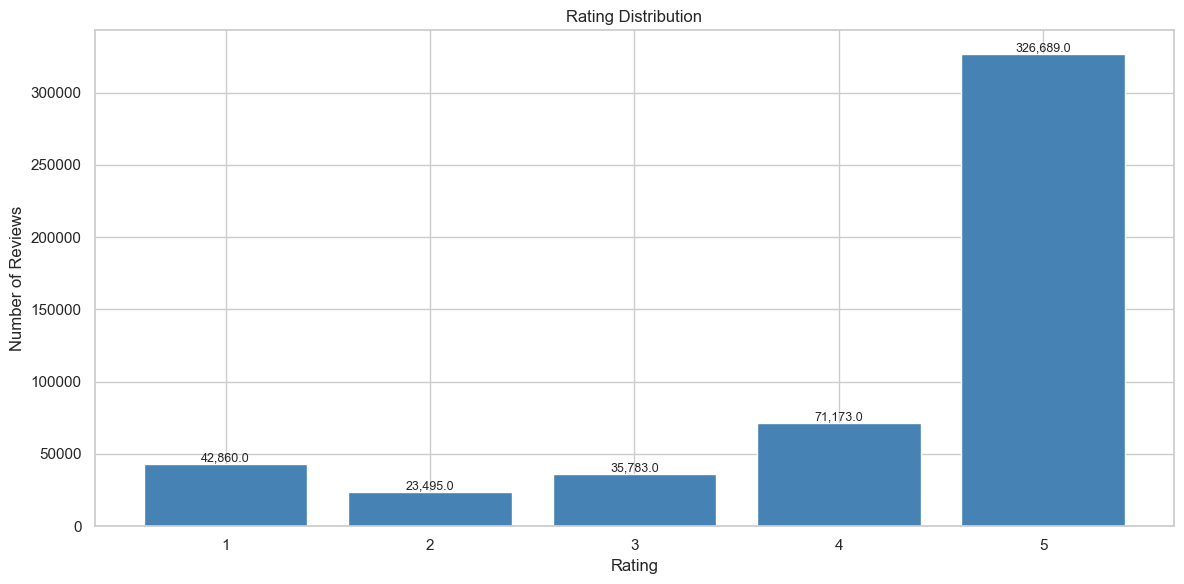

In [3]:
ratings = pd.read_sql("SELECT rating, COUNT(*) as count FROM reviews GROUP BY rating ORDER BY rating", engine)

fig, ax = plt.subplots()
ax.bar(ratings["rating"], ratings["count"], color="steelblue", edgecolor="white")
ax.set_xlabel("Rating")
ax.set_ylabel("Number of Reviews")
ax.set_title("Rating Distribution")
ax.set_xticks([1, 2, 3, 4, 5])
for i, row in ratings.iterrows():
    ax.text(row["rating"], row["count"], f"{row['count']:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

## 3. Reviews Over Time

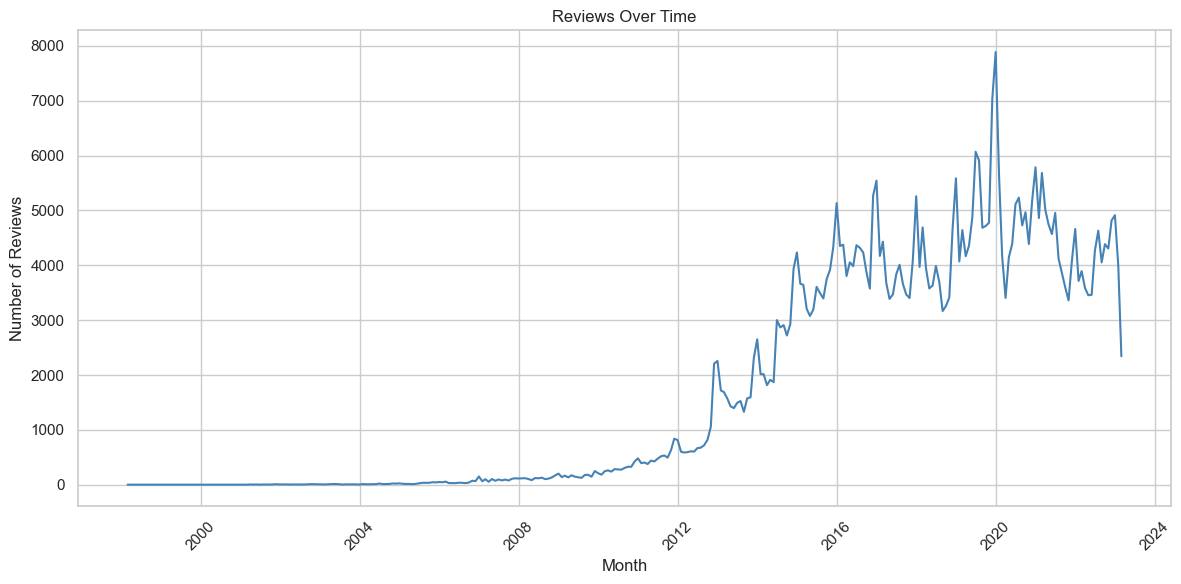

In [4]:
time_df = pd.read_sql(
    "SELECT DATE_TRUNC('month', timestamp) as month, COUNT(*) as count FROM reviews WHERE timestamp IS NOT NULL GROUP BY month ORDER BY month",
    engine,
)

fig, ax = plt.subplots()
ax.plot(time_df["month"], time_df["count"], color="steelblue", linewidth=1.5)
ax.set_xlabel("Month")
ax.set_ylabel("Number of Reviews")
ax.set_title("Reviews Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Top 20 Most Reviewed Products

In [5]:
top_products = pd.read_sql(
    """
    SELECT r.asin, p.title, COUNT(*) as review_count, ROUND(AVG(r.rating)::numeric, 2) as avg_rating
    FROM reviews r
    LEFT JOIN products p ON r.parent_asin = p.parent_asin
    GROUP BY r.asin, p.title
    ORDER BY review_count DESC
    LIMIT 20
    """,
    engine,
)
top_products

,asin,title,review_count,avg_rating
0,B01G8JO5F2,"Senso Bluetooth Headphones, Best Wireless Spor...",5007,3.84
1,B00ZV9RDKK,"Fire TV Stick with Alexa Voice Remote, streami...",1746,4.43
2,B079QHML21,Fire TV Stick 4K streaming device with Alexa V...,1256,4.57
3,B01DFKC2SO,Echo Dot (2nd Generation) - Smart speaker with...,1145,4.38
4,B013J7WUGC,Edifier P841 Comfortable Noise Isolating Over-...,864,4.42
5,B07FZ8S74R,"Echo Dot (3rd Gen, 2018 release) - Smart speak...",845,4.59
6,B0791TX5P5,Fire TV Stick streaming device with Alexa buil...,813,4.54
7,B00TSUGXKE,"Fire Tablet with Alexa, 7"" Display, 16 GB, Blu...",746,4.22
8,B010OYASRG,"OontZ Angle 3 Bluetooth Speaker, Portable Wire...",573,4.42
9,B01MZEEFNX,"Amazon Smart Plug, for home automation, Works ...",563,4.66


## 5. Word Cloud of Negative Reviews (1-2 stars)

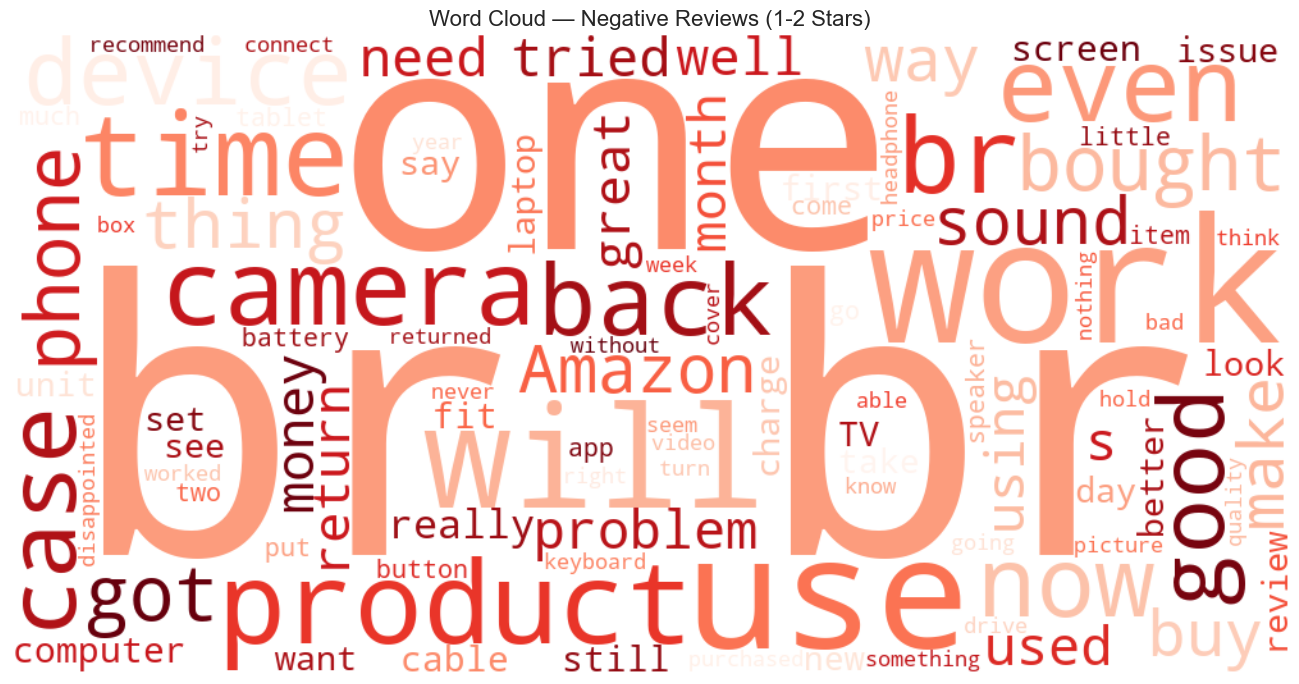

In [6]:
from wordcloud import WordCloud

negative = pd.read_sql(
    "SELECT text FROM reviews WHERE rating <= 2 AND text IS NOT NULL LIMIT 10000",
    engine,
)

all_text = " ".join(negative["text"].tolist())
wc = WordCloud(width=1000, height=500, background_color="white", colormap="Reds", max_words=100).generate(all_text)

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("Word Cloud — Negative Reviews (1-2 Stars)", fontsize=16)
plt.tight_layout()
plt.show()

## 6. Sample NER Extractions

NER = Named Entity Recognition

  It reads review text and pulls out structured info:

  Input:  "The battery died after 2 weeks and the screen is cracked"

  Output: {
    components: ["battery", "screen"],
    issues: ["cracked"],
    time_refs: ["2 weeks"]
  }

  We built a custom spaCy NER pipeline with 40+ component patterns (battery, bluetooth, USB, charger...) and 38+ issue patterns       
  (broken, defective, overheating, slow...).

  Why we need it: Raw review text is unstructured. The models and agents need to know what component has what problem. NER turns messy
   text into structured data that feeds into the feature pipeline, classifier, and LangGraph agents.

In [7]:
from src.features.ner_extractor import load_nlp, extract_from_text

nlp = load_nlp()

sample_reviews = pd.read_sql(
    "SELECT text FROM reviews WHERE rating <= 2 AND text IS NOT NULL AND LENGTH(text) > 50 LIMIT 20",
    engine,
)

for _, row in sample_reviews.iterrows():
    entities = extract_from_text(nlp, row["text"])
    if entities["components"] or entities["issues"]:
        print(f"Review: {row['text'][:120]}...")
        print(f"  Components: {entities['components']}")
        print(f"  Issues: {entities['issues']}")
        print()

Review: These are battery powered cameras! I don’t care what the reviews say about incredible battery life. I read these and rel...
  Components: ['camera', 'battery']
  Issues: []

Review: Battery charged up in a couple hours. It then discharged, without being in the camera, in less than one day. Junk produc...
  Components: ['camera', 'battery']
  Issues: []

Review: This Samsung Chromebook arrived in a tattered box for a Lenovo Chromebook. Upon unboxing, I found they boxed it up with ...
  Components: ['cable', 'port', 'plug', 'adapter', 'screen', 'power']
  Issues: []

Review: If you’re looking for a shortwave combo radio this isn’t a good choice. I could not receive signals on any bands other t...
  Components: ['antenna']
  Issues: []

Review: So, apparently this cable, an Amazon Basics product, is made in China. Presently, while mostly stuck at home during the ...
  Components: ['cable']
  Issues: []

Review: THIS REVIEW IS FOR THE ZBOX Bi323-U.<br /><br />DO NOT BUY FROM THIS M

## 7. Review Length Distribution

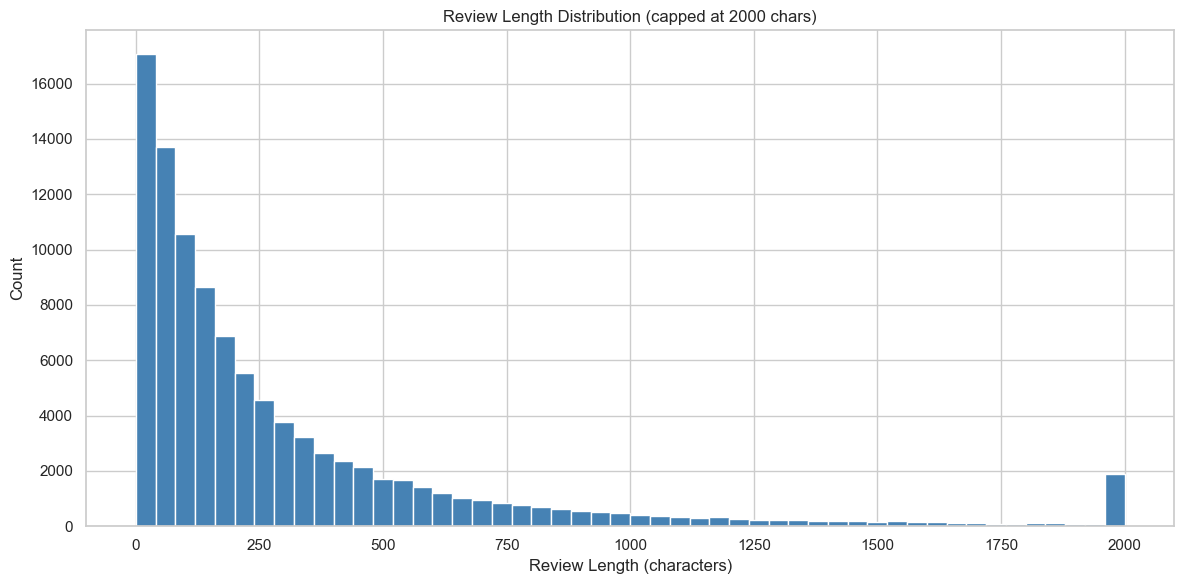

Median length: 160 chars
Mean length: 328 chars


In [8]:
lengths = pd.read_sql(
    "SELECT LENGTH(text) as text_length FROM reviews WHERE text IS NOT NULL LIMIT 100000",
    engine,
)

fig, ax = plt.subplots()
ax.hist(lengths["text_length"].clip(upper=2000), bins=50, color="steelblue", edgecolor="white")
ax.set_xlabel("Review Length (characters)")
ax.set_ylabel("Count")
ax.set_title("Review Length Distribution (capped at 2000 chars)")
plt.tight_layout()
plt.show()

print(f"Median length: {lengths['text_length'].median():.0f} chars")
print(f"Mean length: {lengths['text_length'].mean():.0f} chars")

## 8. Helpful Votes Distribution

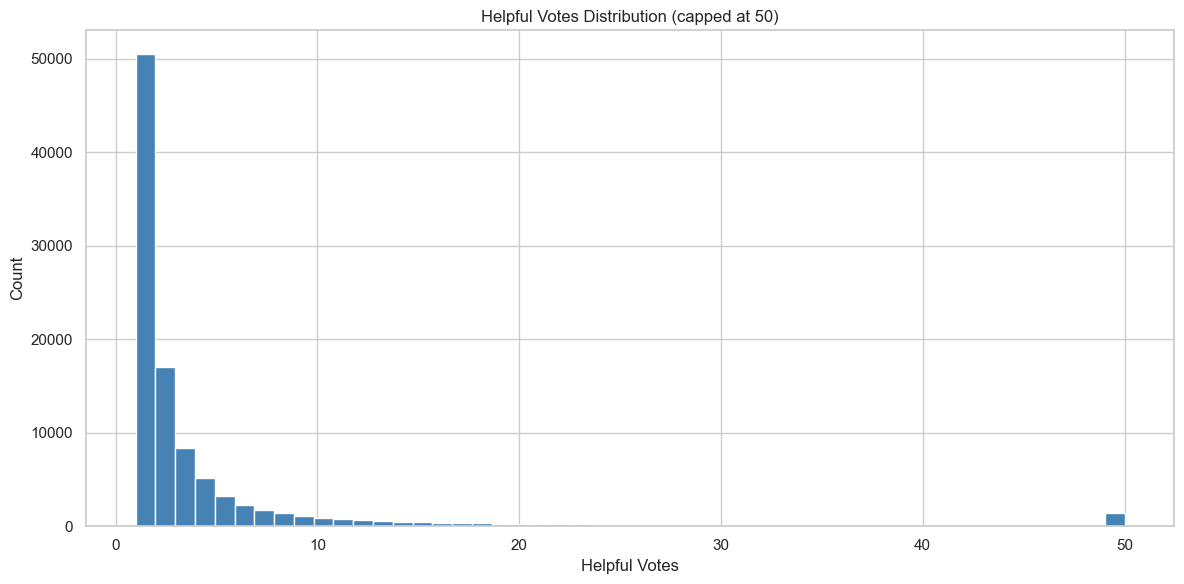

Reviews with >0 helpful votes: 100,000
Median helpful votes (when >0): 1


In [9]:
helpful = pd.read_sql(
    "SELECT helpful_votes FROM reviews WHERE helpful_votes IS NOT NULL AND helpful_votes > 0 LIMIT 100000",
    engine,
)

fig, ax = plt.subplots()
ax.hist(helpful["helpful_votes"].clip(upper=50), bins=50, color="steelblue", edgecolor="white")
ax.set_xlabel("Helpful Votes")
ax.set_ylabel("Count")
ax.set_title("Helpful Votes Distribution (capped at 50)")
plt.tight_layout()
plt.show()

print(f"Reviews with >0 helpful votes: {len(helpful):,}")
print(f"Median helpful votes (when >0): {helpful['helpful_votes'].median():.0f}")